## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000011DE6EA3490> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'

In [4]:
years = range(2025, 2026)

In [5]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled_mean_rain_shp.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2025 | (894884, 44)


In [6]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [7]:
del df
del timelines

gc.collect()

0

In [8]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,23.658820,41.335420,0,2025-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13893.000000,13684.000000,0.000000,1,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.260870,0.000000,0.000000,0.000000,0.000000,2.000000,2,2
1,23.658820,41.335420,0,2025-01-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,13803.000000,13667.000000,0.000000,2,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.260870,0.000000,0.000000,0.000000,0.000000,2.000000,2,2
2,23.658820,41.335420,0,2025-01-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,13803.000000,13667.000000,6.450000,3,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.260870,6.450000,6.450000,6.450000,6.450000,2.000000,2,2
3,23.658820,41.335420,0,2025-01-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,13803.000000,13546.000000,4.760000,4,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.260870,11.210000,11.210000,11.210000,11.210000,2.000000,2,2
4,23.658820,41.335420,0,2025-01-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,13803.000000,13649.000000,2.020000,5,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.260870,13.230000,13.230000,13.230000,13.230000,2.000000,2,2


In [9]:
timeline_file.shape

(894884, 44)

In [10]:
# wnv_file.head()

In [11]:
# wnv_file.shape

In [12]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [13]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [14]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,23.658820,41.335420,0,2025-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.710000,0.530000,0.000000,1,4.148710,1.491290,1.224286,-4.179286,11.500714,3.874138,13.563043,6.395217,0.000000,0.000000,0.000000,0.000000,2.000000,2,2
1,23.658820,41.335420,0,2025-01-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,2.910000,0.190000,0.000000,2,4.148710,1.491290,1.224286,-4.179286,11.500714,3.874138,13.563043,6.395217,0.000000,0.000000,0.000000,0.000000,2.000000,2,2
2,23.658820,41.335420,0,2025-01-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,2.910000,0.190000,6.450000,3,4.148710,1.491290,1.224286,-4.179286,11.500714,3.874138,13.563043,6.395217,6.450000,6.450000,6.450000,6.450000,2.000000,2,2
3,23.658820,41.335420,0,2025-01-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,2.910000,-2.230000,4.760000,4,4.148710,1.491290,1.224286,-4.179286,11.500714,3.874138,13.563043,6.395217,11.210000,11.210000,11.210000,11.210000,2.000000,2,2
4,23.658820,41.335420,0,2025-01-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,2.910000,-0.170000,2.020000,5,4.148710,1.491290,1.224286,-4.179286,11.500714,3.874138,13.563043,6.395217,13.230000,13.230000,13.230000,13.230000,2.000000,2,2


In [15]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [16]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [17]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [18]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,23.658820,41.335420,0,2025-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.710000,0.530000,0.000000,1,4.148710,1.491290,1.224286,-4.179286,11.500714,3.874138,13.563043,6.395217,0.000000,0.000000,0.000000,0.000000,2.000000,2,2,2.620000,2.820000,-1.477500,7.687426,9.979130,0.500000,0.866025
1,23.658820,41.335420,0,2025-01-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,2.910000,0.190000,0.000000,2,4.148710,1.491290,1.224286,-4.179286,11.500714,3.874138,13.563043,6.395217,0.000000,0.000000,0.000000,0.000000,2.000000,2,2,1.550000,2.820000,-1.477500,7.687426,9.979130,0.500000,0.866025
2,23.658820,41.335420,0,2025-01-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,2.910000,0.190000,6.450000,3,4.148710,1.491290,1.224286,-4.179286,11.500714,3.874138,13.563043,6.395217,6.450000,6.450000,6.450000,6.450000,2.000000,2,2,1.550000,2.820000,-1.477500,7.687426,9.979130,0.500000,0.866025
3,23.658820,41.335420,0,2025-01-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,2.910000,-2.230000,4.760000,4,4.148710,1.491290,1.224286,-4.179286,11.500714,3.874138,13.563043,6.395217,11.210000,11.210000,11.210000,11.210000,2.000000,2,2,0.340000,2.820000,-1.477500,7.687426,9.979130,0.500000,0.866025
4,23.658820,41.335420,0,2025-01-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.070950,-0.082637,-0.070950,0.087655,0.112251,0.138840,0.112251,2.910000,-0.170000,2.020000,5,4.148710,1.491290,1.224286,-4.179286,11.500714,3.874138,13.563043,6.395217,13.230000,13.230000,13.230000,13.230000,2.000000,2,2,1.370000,2.820000,-1.477500,7.687426,9.979130,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
894879,26.607560,41.407290,3265,2025-09-27,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2025,9,0.185091,-0.156714,-0.279375,0.156714,0.254759,-0.081910,-0.320579,0.081910,0.040634,0.043945,0.028179,0.043945,29.590000,18.810000,0.000000,27,8.861034,3.355806,6.318800,-2.536429,16.690000,3.741034,20.703333,7.435217,0.000000,0.000000,0.064314,202.580191,4.000000,2,1,24.200000,6.108420,1.891186,10.215517,14.069275,-1.000000,-0.000000
894880,26.607560,41.407290,3265,2025-09-28,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2025,9,0.185091,-0.156714,-0.279375,0.156714,0.254759,-0.081910,-0.320579,0.081910,0.040634,0.043945,0.028179,0.043945,29.590000,18.810000,0.000000,28,8.861034,3.355806,6.318800,-2.536429,16.690000,3.741034,20.703333,7.435217,0.000000,0.000000,0.064314,202.580191,4.000000,2,1,24.200000,6.108420,1.891186,10.215517,14.069275,-1.000000,-0.000000
894881,26.607560,41.407290,3265,2025-09-29,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",E

In [19]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [20]:
gc.collect()

17

In [21]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [22]:
del timeline_file
gc.collect()

0

In [23]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [24]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [25]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2025-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2025.000000,1.000000,0.048777,0.250378,0.216915,-0.250378,0.161828,0.196295,-0.023858,-0.196295,0.090690,0.107551,0.165881,0.107551,4.148710,1.491290,2.820000,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.733548,0.870000,3.790000,22.740000,22.740000,-1.290000,-2.230000,8.510000,5.190000,22.740000
1,0,2025-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2025.000000,2.000000,0.211984,0.023017,-0.109929,-0.023017,0.254488,-0.026693,-0.204481,0.026693,0.050779,0.055098,0.083443,0.055098,1.224286,-4.179286,-1.477500,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.447857,2.490000,5.090000,12.540000,35.279999,-2.930000,-7.950000,7.970000,2.110000,12.540000
2,0,2025-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2025.000000,3.000000,0.295217,-0.006585,-0.252513,0.006585,0.299747,-0.028416,-0.292668,0.028416,0.038243,0.050534,0.067112,0.050534,11.500714,3.874138,7.779286,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,9.877742,170.119997,251.629995,305.819993,341.489992,4.950000,-1.270000,15.950000,9.730000,306.209993
3,0,2025-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2025.000000,4.000000,0.253624,0.255137,-0.173633,-0.255137,0.286947,0.110002,-0.202032,-0.110002,0.054412,0.046881,0.049679,0.046881,13.563043,6.395217,9.979130,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,3.061667,32.939999,51.639999,91.849998,433.339990,0.590000,2.430000,22.930000,10.390000,91.849998
4,0,2025-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2025.000000,5.000000,0.732759,0.429699,-0.387695,-0.429699,0.687020,0.381177,-0.359952,-0.381177,0.080908,0.046021,0.094076,0.046021,15.978000,13.060000,14.010000,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.511667,0.000000,0.000000,3.070000,436.409989,14.090000,11.590000,20.050000,13.550000,3.070000


In [26]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2025-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2025.000000,1.000000,0.048777,0.250378,0.216915,-0.250378,0.161828,0.196295,-0.023858,-0.196295,0.090690,0.107551,0.165881,0.107551,4.148710,1.491290,2.820000,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.733548,0.870000,3.790000,22.740000,22.740000,-1.290000,-2.230000,8.510000,5.190000,22.740000
1,0,2025-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2025.000000,2.000000,0.211984,0.023017,-0.109929,-0.023017,0.254488,-0.026693,-0.204481,0.026693,0.050779,0.055098,0.083443,0.055098,1.224286,-4.179286,-1.477500,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.447857,2.490000,5.090000,12.540000,35.279999,-2.930000,-7.950000,7.970000,2.110000,12.540000
2,0,2025-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2025.000000,3.000000,0.295217,-0.006585,-0.252513,0.006585,0.299747,-0.028416,-0.292668,0.028416,0.038243,0.050534,0.067112,0.050534,11.500714,3.874138,7.779286,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,9.877742,170.119997,251.629995,305.819993,341.489992,4.950000,-1.270000,15.950000,9.730000,306.209993
3,0,2025-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2025.000000,4.000000,0.253624,0.255137,-0.173633,-0.255137,0.286947,0.110002,-0.202032,-0.110002,0.054412,0.046881,0.049679,0.046881,13.563043,6.395217,9.979130,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,3.061667,32.939999,51.639999,91.849998,433.339990,0.590000,2.430000,22.930000,10.390000,91.849998
4,0,2025-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2025.000000,5.000000,0.732759,0.429699,-0.387695,-0.429699,0.687020,0.381177,-0.359952,-0.381177,0.080908,0.046021,0.094076,0.046021,15.978000,13.060000,14.010000,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.511667,0.000000,0.000000,3.070000,436.409989,14.090000,11.590000,20.050000,13.550000,3.070000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32655,3265,2025-06,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4.000000,2.000000,1.000000,2025.000000,6.000000,0.381715,0.080804,-0.339803,-0.080804,0.418554,0.105143,-0.347862,-0.105143,0.053095,0.058511,0.036080,0.058511,32.945200,19.544615,26.283200,8.861034,6.318800,16.690000,20.703333,3.355806,-2.536429,3.741034,7.435217,6.108420,1.891186,10.215517,14.069275,0.004990,0.144706,0.144706,0.144706,192.466858,28.130000,16.950000,38.050000,23.210000,0.144706
32656,3265,2025-07,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτει

In [27]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [28]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [29]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [30]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2025-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,1,0.048777,0.250378,0.216915,-0.250378,0.161828,0.196295,-0.023858,-0.196295,0.090690,0.107551,0.165881,0.107551,4.148710,1.491290,2.820000,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.733548,0.870000,3.790000,22.740000,22.740000,22.740000,-2.230000,8.510000
1,0,2025-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,2,0.211984,0.023017,-0.109929,-0.023017,0.254488,-0.026693,-0.204481,0.026693,0.050779,0.055098,0.083443,0.055098,1.224286,-4.179286,-1.477500,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.447857,2.490000,5.090000,12.540000,35.279999,12.540000,-7.950000,7.970000
2,0,2025-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,3,0.295217,-0.006585,-0.252513,0.006585,0.299747,-0.028416,-0.292668,0.028416,0.038243,0.050534,0.067112,0.050534,11.500714,3.874138,7.779286,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,9.877742,170.119997,251.629995,305.819993,341.489992,306.209993,-1.270000,15.950000
3,0,2025-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,4,0.253624,0.255137,-0.173633,-0.255137,0.286947,0.110002,-0.202032,-0.110002,0.054412,0.046881,0.049679,0.046881,13.563043,6.395217,9.979130,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,3.061667,32.939999,51.639999,91.849998,433.339990,91.849998,0.590000,22.930000
4,0,2025-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,5,0.732759,0.429699,-0.387695,-0.429699,0.687020,0.381177,-0.359952,-0.381177,0.080908,0.046021,0.094076,0.046021,15.978000,13.060000,14.010000,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.511667,0.000000,0.000000,3.070000,436.409989,3.070000,11.590000,20.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32655,3265,2025-06,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4,2,1,2025,6,0.381715,0.080804,-0.339803,-0.080804,0.418554,0.105143,-0.347862,-0.105143,0.053095,0.058511,0.036080,0.058511,32.945200,19.544615,26.283200,8.861034,6.318800,16.690000,20.703333,3.355806,-2.536429,3.741034,7.435217,6.108420,1.891186,10.215517,14.069275,0.004990,0.144706,0.144706,0.144706,192.466858,0.144706,16.950000,38.050000
32656,3265,2025-07,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4,2,1,2025,7,0.198721,-0.078176,-0.334130,0.078176,0.297327,-0.002982,-0.369870,0.002982,0.060244,0.052322,0.028728,0.052322,37.454138,23.335517,30.394828,8.861034,6.318800,16.690000,20.703333,3.355806,-2.536429,3.741034,7.435217,6.108420,1.891186,10.215517,14.069275,0.160784,0.000000,4.984314,4.984314,197.451171,4.984314,19.770000,40.250000
3

### Add Geomorphological and Land Cover/Use

In [31]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [32]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [33]:
dataset_locations

,x,y
0,23.658820,41.335420
1,23.658820,41.335420
2,23.658820,41.353390
3,23.658820,41.371350
4,23.682410,41.335420
...,...,...
4494,26.583970,41.497120
4495,26.607560,41.353390
4496,26.607560,41.371350
4497,26.607560,41.389320


In [34]:
dataset_locations_per_year

,x,y,year
0,23.658820,41.335420,2025
1,23.658820,41.335420,2025
2,23.658820,41.353390,2025
3,23.658820,41.371350,2025
4,23.682410,41.335420,2025
...,...,...,...
4494,26.583970,41.497120,2025
4495,26.607560,41.353390,2025
4496,26.607560,41.371350,2025
4497,26.607560,41.389320,2025


In [35]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [36]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 6.476848622997191e-06
Max distance: 0.0004949449883773354


In [37]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_1484\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [38]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
1,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
2,23.658820,41.353390,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.000000,7.312587
3,23.658820,41.371350,15511.617699,3080.473528,12,215.223506,1485.689343,175.139206,0.000000,1.647387
4,23.682410,41.335420,11769.057994,925.127006,27,138.894382,938.467554,176.004728,0.000000,9.000000
...,...,...,...,...,...,...,...,...,...,...
4494,26.583970,41.497120,12913.516660,1512.420906,0,116.586966,25.544792,180.275374,0.000000,2.540235
4495,26.607560,41.353390,4280.496542,1670.716589,6,222.081729,110.061641,181.681546,0.000000,1.784513
4496,26.607560,41.371350,5534.250191,1642.856322,1,172.812015,100.209139,174.708787,0.000000,2.583181
4497,26.607560,41.389320,7118.816477,486.915231,5,116.740570,30.772462,178.290475,0.000000,3.071251


In [39]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [40]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [41]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [42]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
1,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
2,23.658820,41.353390,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.000000,7.312587
3,23.658820,41.371350,15511.617699,3080.473528,12,215.223506,1485.689343,175.139206,0.000000,1.647387
4,23.682410,41.335420,11769.057994,925.127006,27,138.894382,938.467554,176.004728,0.000000,9.000000
...,...,...,...,...,...,...,...,...,...,...
4494,26.583970,41.497120,12913.516660,1512.420906,0,116.586966,25.544792,180.275374,0.000000,2.540235
4495,26.607560,41.353390,4280.496542,1670.716589,6,222.081729,110.061641,181.681546,0.000000,1.784513
4496,26.607560,41.371350,5534.250191,1642.856322,1,172.812015,100.209139,174.708787,0.000000,2.583181
4497,26.607560,41.389320,7118.816477,486.915231,5,116.740570,30.772462,178.290475,0.000000,3.071251


In [43]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [44]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [45]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [46]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [47]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [48]:
landcover_2025 = landcover_2024 = landcover_2023 = landcover_2022

In [49]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2025
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449883773354


In [50]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [51]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,23.658820,41.335420,2025,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
1,23.658820,41.335420,2025,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
2,23.658820,41.353390,2025,31,84.000000,30,84.000000,30,84.000000,10,10,1,6,6,2,0
3,23.658820,41.371350,2025,31,95.000000,30,95.000000,30,95.000000,10,10,1,6,6,2,0
4,23.682410,41.335420,2025,14,99.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4494,26.583970,41.497120,2025,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
4495,26.607560,41.353390,2025,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
4496,26.607560,41.371350,2025,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
4497,26.607560,41.389320,2025,31,98.000000,36,99.000000,30,98.000000,12,12,3,5,8,2,0


In [52]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment    float64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment    float64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [53]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [54]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [55]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [56]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2025,1,22.740000,-2.230000,8.510000
1,0,2025,2,12.540000,-7.950000,7.970000
2,0,2025,3,306.209993,-1.270000,15.950000
3,0,2025,4,91.849998,0.590000,22.930000
4,0,2025,5,3.070000,11.590000,20.050000
5,0,2025,6,54.799999,8.990000,30.030000
6,0,2025,7,1.450000,14.670000,32.870000
7,0,2025,8,7.720000,14.930000,30.230000
8,0,2025,9,1.990000,8.270000,25.730000
9,0,2025,10,0.000000,NaN,NaN


In [57]:
# wnv_file.head(5)

In [58]:
# wnv_file

In [59]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32660 entries, 0 to 32659
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype    
---  ------               --------------  -----    
 0   cell_number          32660 non-null  int64    
 1   dt_placement         32660 non-null  period[M]
 2   NUTS1_ID             32660 non-null  object   
 3   NUTS1_NAME           32660 non-null  object   
 4   NUTS2_ID             32660 non-null  object   
 5   NUTS2_NAME           32660 non-null  object   
 6   NUTS3_ID             32660 non-null  object   
 7   NUTS3_NAME           32660 non-null  object   
 8   LAU1_NAME            32660 non-null  object   
 9   x                    32660 non-null  float64  
 10  y                    32660 non-null  float64  
 11  MOUNT_TYPE           32660 non-null  int32    
 12  URBN_TYPE            32660 non-null  int32    
 13  COAST_TYPE           32660 non-null  int32    
 14  year                 32660 non-null  int32    
 15  mo

In [60]:
# wnv_file.info()

In [61]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [62]:
# wnv_file.info()

In [63]:
# wnv_file

In [64]:
# wnv_file['cases'].value_counts()

In [65]:
# wnv_file.cases.sum()

In [66]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [67]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2025-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,1,0.048777,0.250378,0.216915,-0.250378,0.161828,0.196295,-0.023858,-0.196295,0.090690,0.107551,0.165881,0.107551,4.148710,1.491290,2.820000,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.733548,0.870000,3.790000,22.740000,22.740000,22.740000,-2.230000,8.510000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
1,0,2025-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,2,0.211984,0.023017,-0.109929,-0.023017,0.254488,-0.026693,-0.204481,0.026693,0.050779,0.055098,0.083443,0.055098,1.224286,-4.179286,-1.477500,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.447857,2.490000,5.090000,12.540000,35.279999,12.540000,-7.950000,7.970000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
2,0,2025-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,3,0.295217,-0.006585,-0.252513,0.006585,0.299747,-0.028416,-0.292668,0.028416,0.038243,0.050534,0.067112,0.050534,11.500714,3.874138,7.779286,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,9.877742,170.119997,251.629995,305.819993,341.489992,306.209993,-1.270000,15.950000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
3,0,2025-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,4,0.253624,0.255137,-0.173633,-0.255137,0.286947,0.110002,-0.202032,-0.110002,0.054412,0.046881,0.049679,0.046881,13.563043,6.395217,9.979130,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,3.061667,32.939999,51.639999,91.849998,433.339990,91.849998,0.590000,22.930000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
4,0,2025-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,5,0.732759,0.429699,-0.387695,-0.429699,0.687020,0.381177,-0.359952,-0.381177,0.080908,0.046021,0.094076,0.046021,15.978000,13.060000,14.010000,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.511667,0.000000,0.000000,3.070000,436.409989,3.070000,11.590000,20.050000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [68]:
# merged = fillna(merged,{'cases': 0})

In [69]:
# merged['cases'].value_counts()

In [70]:
# merged.cases.sum()

In [71]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

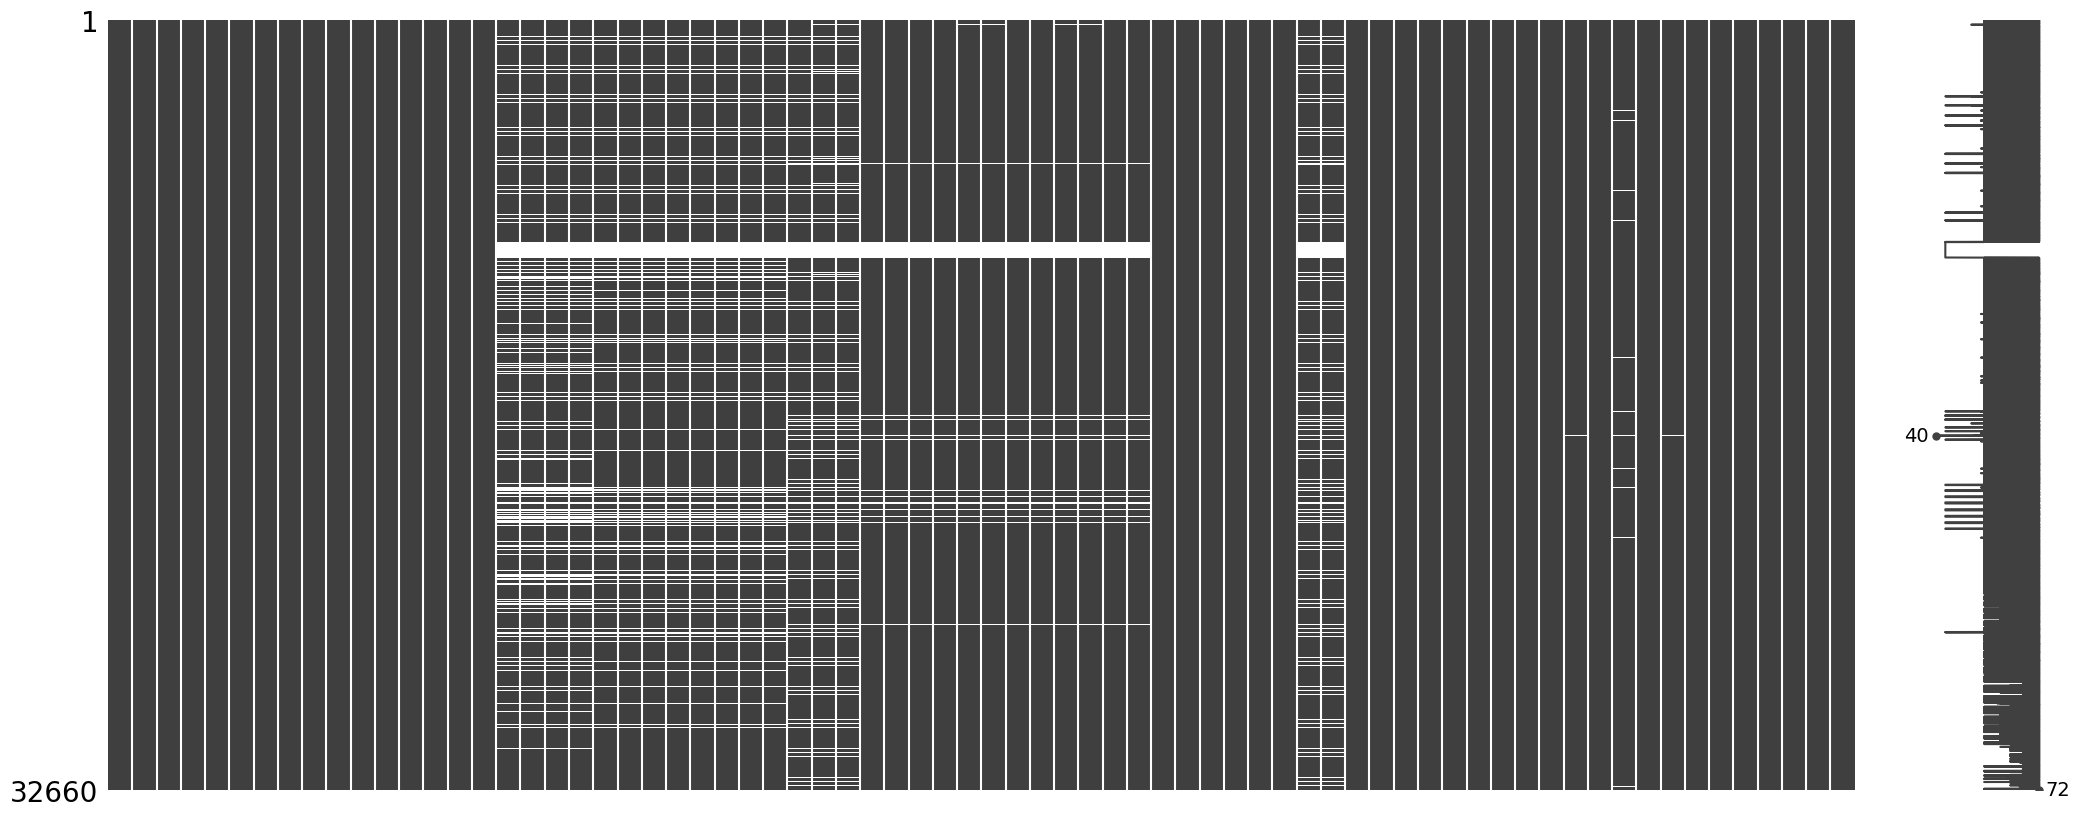

In [72]:
missingno.matrix(merged)

In [73]:
gc.collect()

0

In [74]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

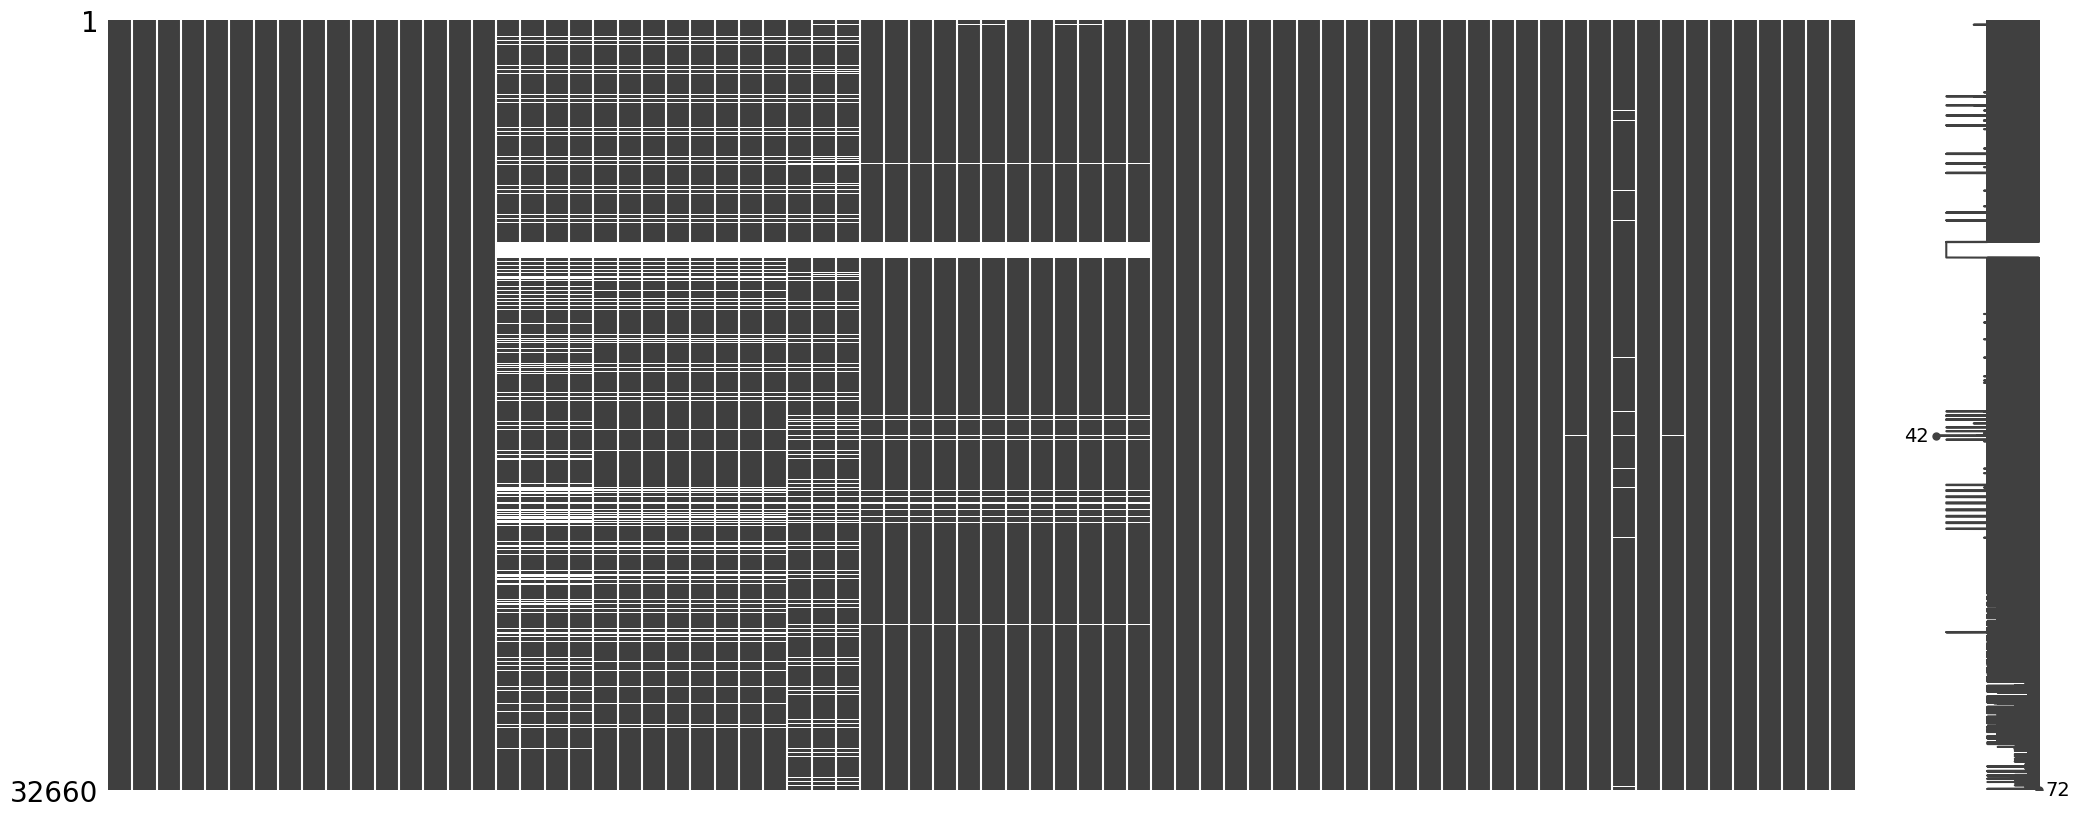

In [75]:
missingno.matrix(merged)

In [76]:
years = merged.year.unique()
years

array([2025])

In [77]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([   0,    1,    2, ..., 3263, 3264, 3265], dtype=int64)

In [78]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [79]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2025,13.500000,16.400000,42.051282,793.725393,32.000000,-7.000000,39.000000,6.000000,18.833333,21.333333,3.333333,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000
1,1,2025,14.850000,19.900000,44.222222,845.264587,37.000000,-8.000000,45.000000,7.333333,19.833333,23.666667,4.166667,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000
2,2,2025,14.550000,21.500000,45.744681,794.582350,37.000000,-10.000000,47.000000,7.166667,19.166667,22.333333,4.500000,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000
3,3,2025,13.700000,15.400000,39.487179,792.394402,32.000000,-7.000000,39.000000,6.666667,19.000000,21.500000,3.500000,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000
4,4,2025,16.000000,20.400000,42.500000,902.773504,40.000000,-8.000000,48.000000,8.500000,21.666667,25.166667,4.500000,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000
5,5,2025,14.700000,21.000000,45.652174,817.924202,38.000000,-8.000000,46.000000,7.500000,19.500000,22.833333,4.333333,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000
6,6,2025,14.050000,18.100000,44.146341,766.104867,34.000000,-7.000000,41.000000,7.333333,18.833333,21.833333,4.166667,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000
7,7,2025,13.700000,15.600000,39.000000,842.351207,33.000000,-7.000000,40.000000,11.000000,19.666667,21.833333,2.833333,476.000000,316.000000,0.000000,202.305688,407.000000,10.000000,55.000000,328.000000
8,8,2025,15.600000,19.200000,42.666667,900.555384,38.000000,-7.000000,45.000000,13.166667,21.333333,24.666667,4.000000,476.000000,316.000000,0.000000,202.305688,407.000000,10.000000,55.000000,328.000000
9,9,2025,16.100000,20.400000,43.404255,916.757571,39.000000,-8.000000,47.000000,13.833333,21.500000,25.333333,4.166667,476.000000,316.000000,0.000000,202.305688,407.000000,10.000000,55.000000,328.000000


In [80]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [81]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2024) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19


In [82]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [83]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1763,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1764,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1765,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000
1766,EL653,2023,14067.000000,71993.000000,29360.000000,115420.000000,13393.000000,67069.000000,32564.000000,113026.000000


In [84]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [85]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1763,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1764,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1765,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000
1766,EL653,2023,14067.000000,71993.000000,29360.000000,115420.000000,13393.000000,67069.000000,32564.000000,113026.000000


In [86]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

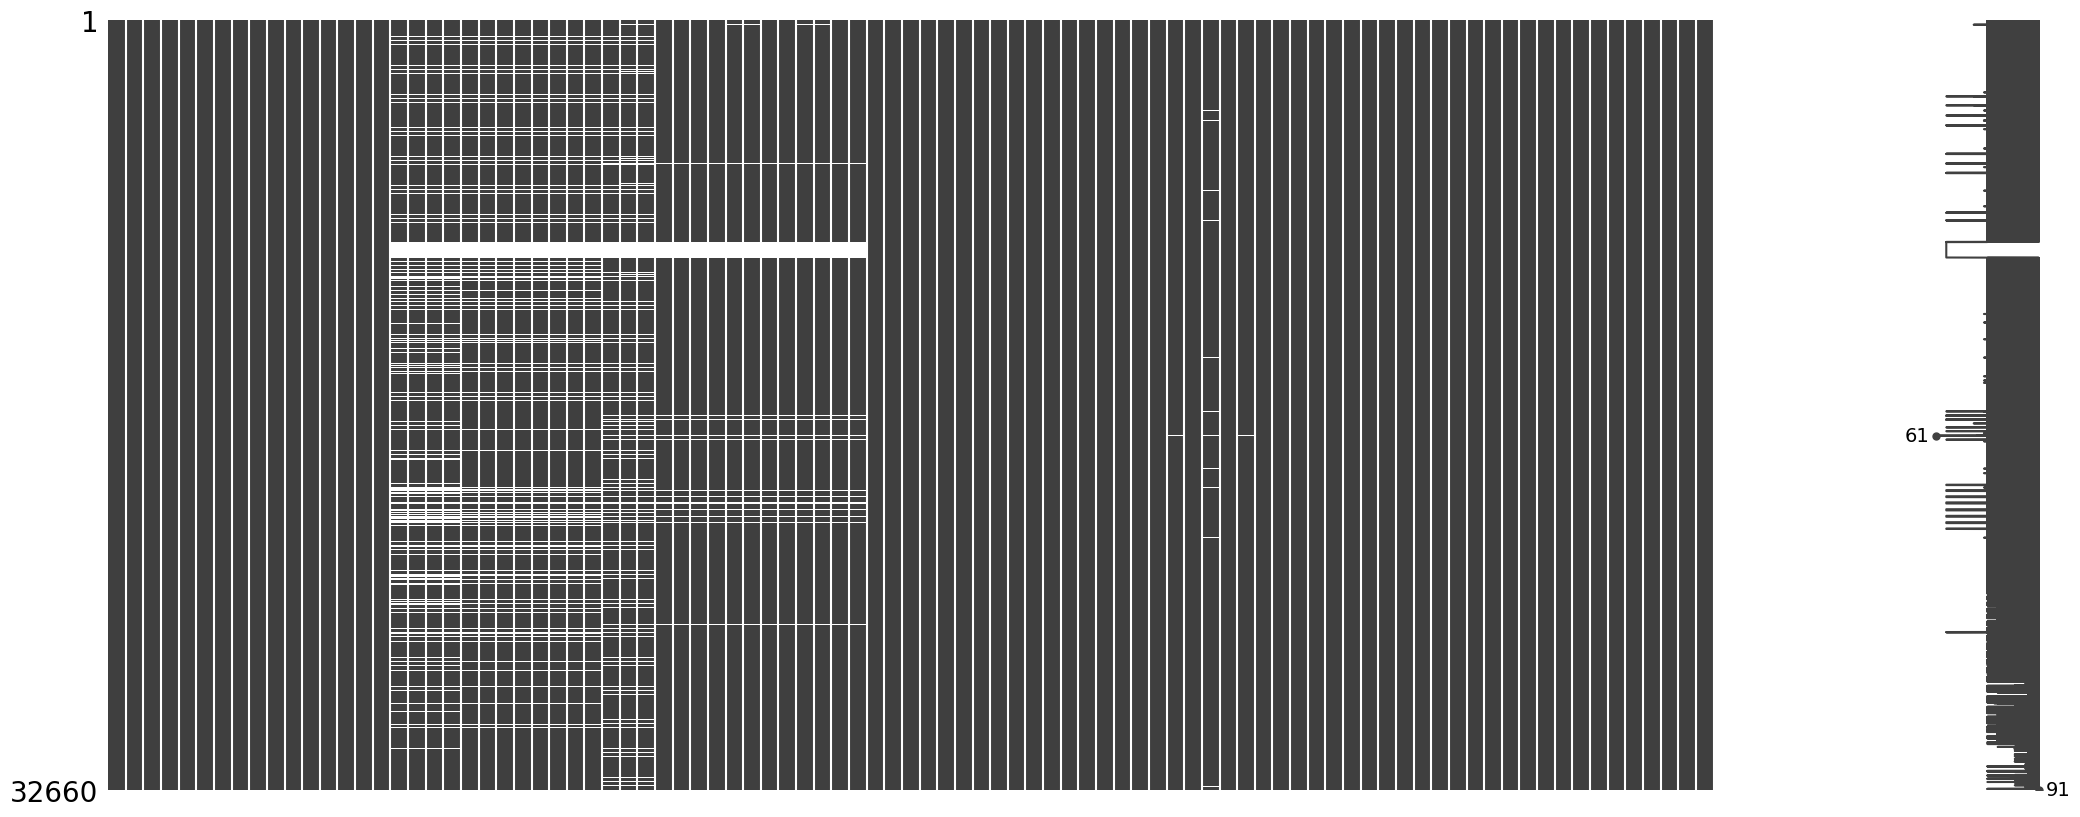

In [87]:
missingno.matrix(dataset)

In [88]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [89]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,9725.080000
1,EL301,2001,10452.130000
2,EL301,2002,11780.170000
3,EL301,2003,12522.310000
4,EL301,2004,13769.510000
...,...,...,...
1191,EL653,2018,3207.990000
1192,EL653,2019,3243.040000
1193,EL653,2020,2907.590000
1194,EL653,2021,3090.650000


In [90]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [91]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,9725.080000
1,EL301,2001,10452.130000
2,EL301,2002,11780.170000
3,EL301,2003,12522.310000
4,EL301,2004,13769.510000
...,...,...,...
1191,EL653,2018,3207.990000
1192,EL653,2019,3243.040000
1193,EL653,2020,2907.590000
1194,EL653,2021,3090.650000


In [92]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

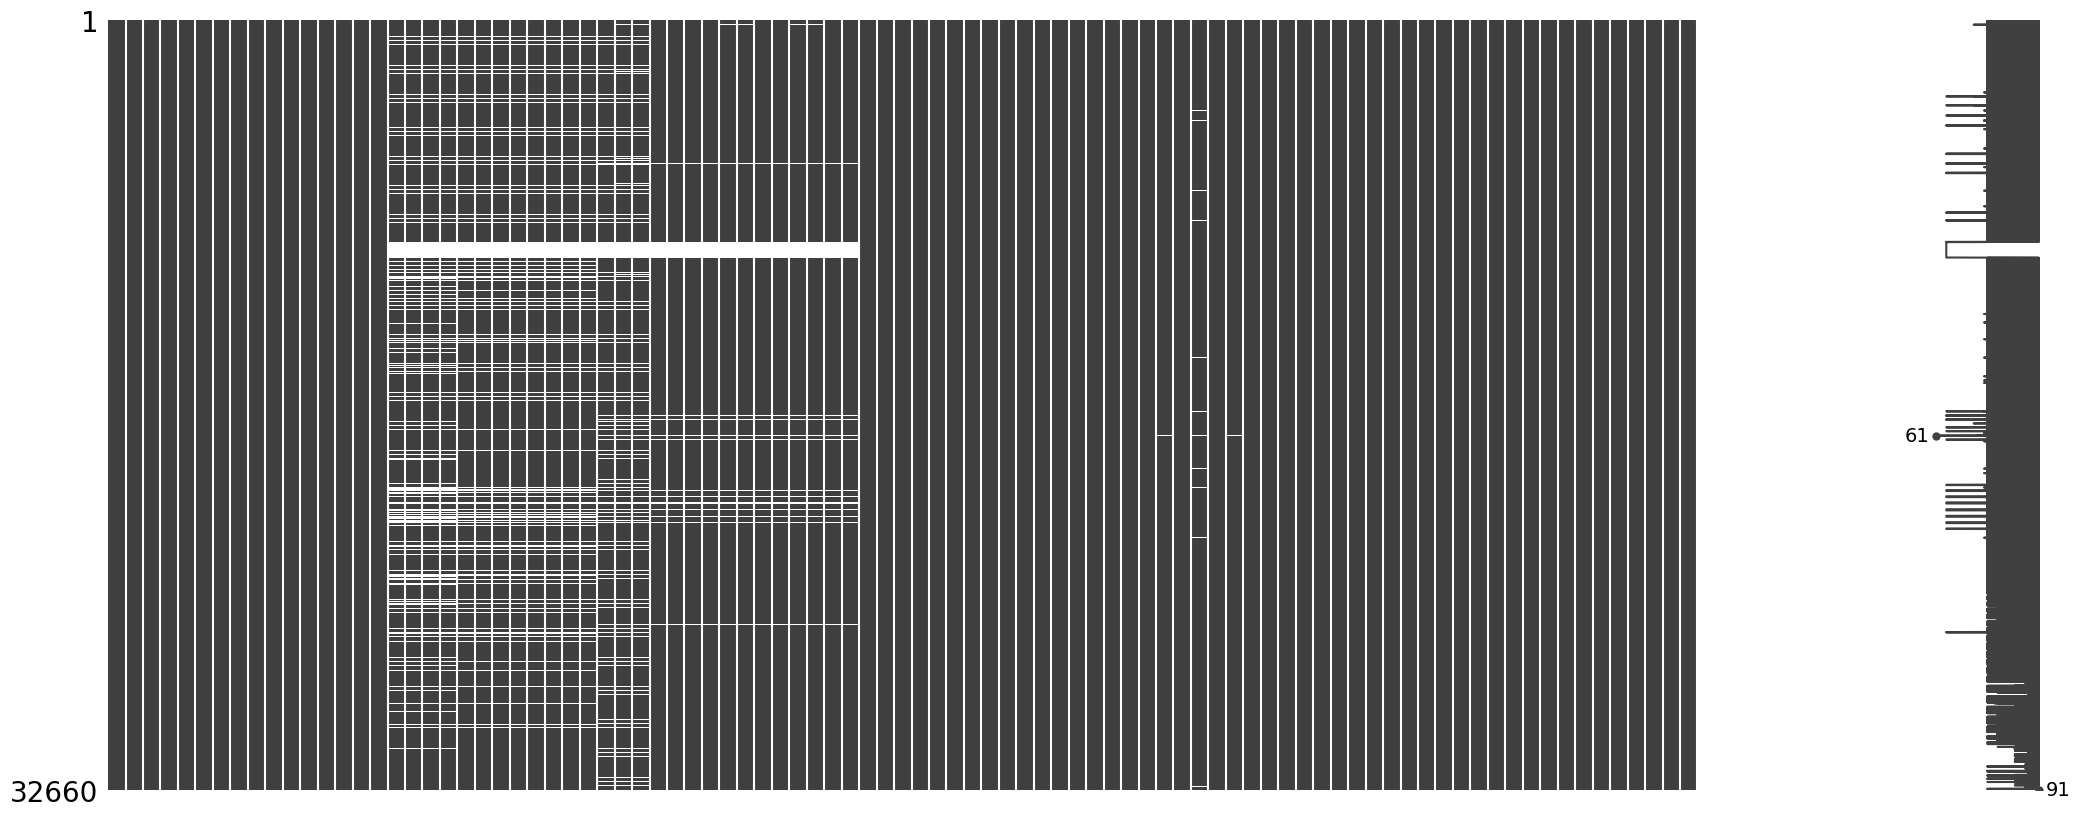

In [93]:
missingno.matrix(dataset)

In [94]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [95]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
818,EL653,2019,3278.000000,3737.000000
819,EL653,2020,4572.000000,4962.000000
820,EL653,2021,3040.000000,3666.000000
821,EL653,2022,11830.000000,12294.000000


In [96]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [97]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
818,EL653,2019,3278.000000,3737.000000
819,EL653,2020,4572.000000,4962.000000
820,EL653,2021,3040.000000,3666.000000
821,EL653,2022,11830.000000,12294.000000


In [98]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

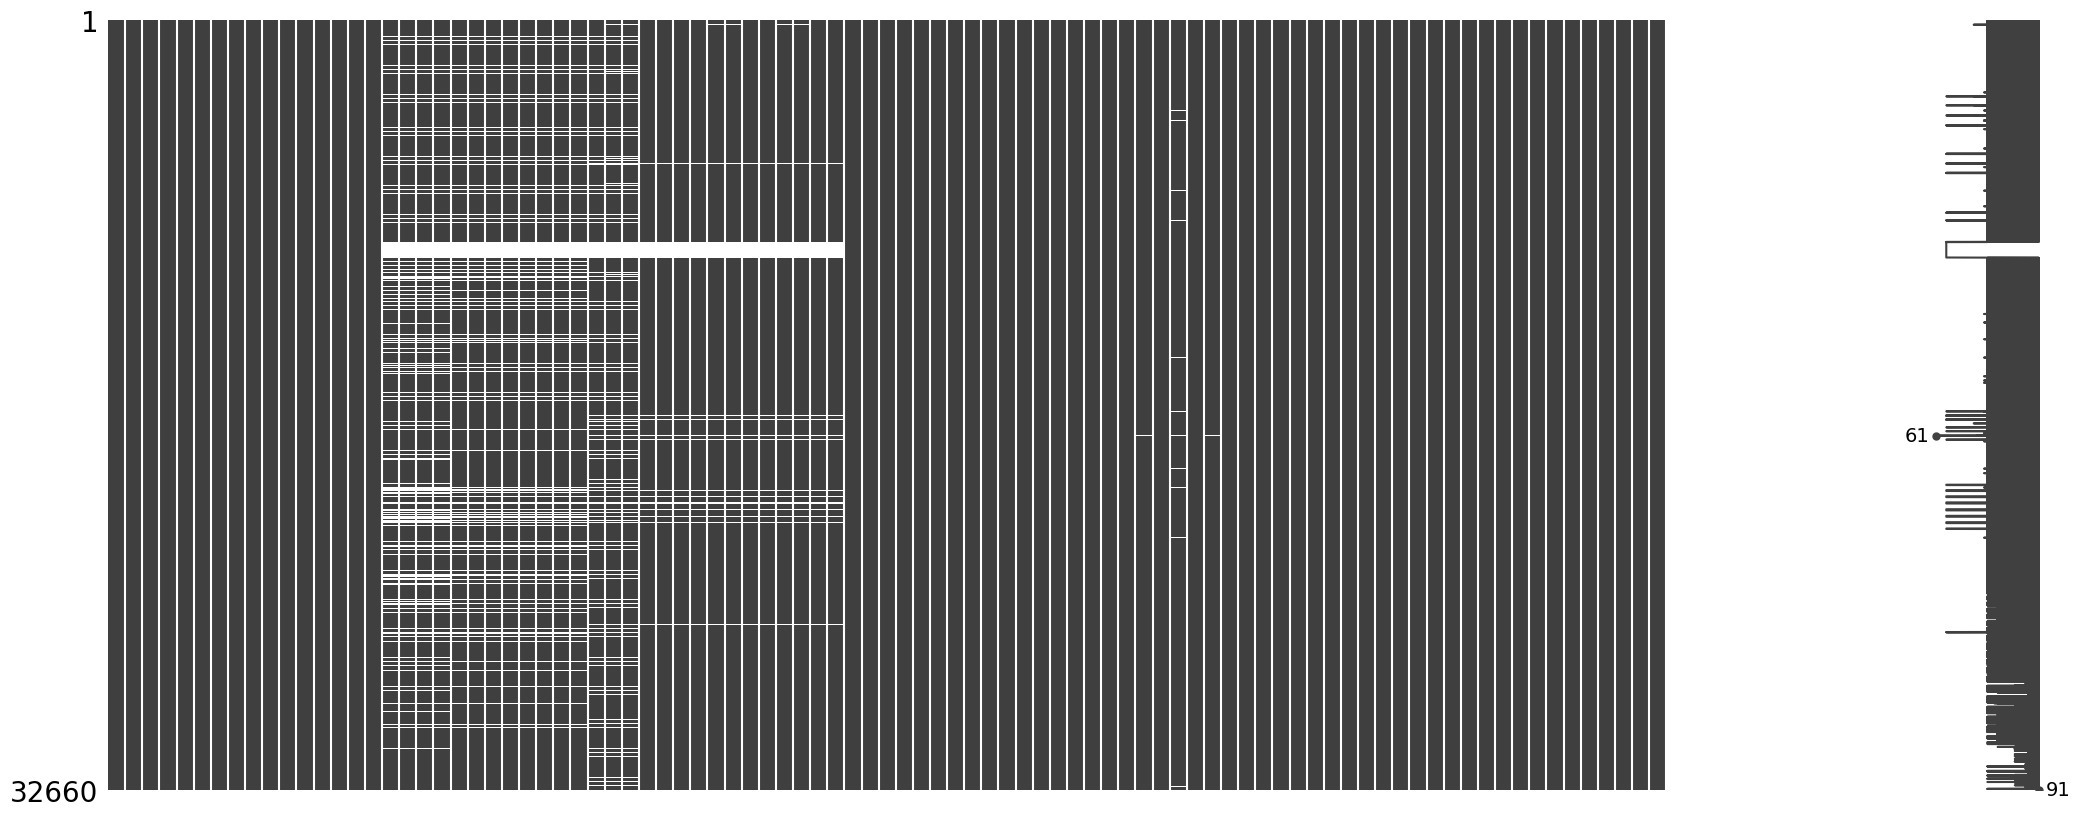

In [99]:
missingno.matrix(dataset)

In [100]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [101]:
missing

,Column,Missing
16,ndvi,17.372900
17,ndmi,17.372900
18,ndwi,17.372900
19,ndbi,17.372900
20,ndvi_mean,14.409100
21,ndmi_mean,14.409100
22,ndwi_mean,14.409100
23,ndbi_mean,14.409100
24,ndvi_std,14.409100
25,ndmi_std,14.409100


In [102]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2025-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,1,0.048777,0.250378,0.216915,-0.250378,0.161828,0.196295,-0.023858,-0.196295,0.090690,0.107551,0.165881,0.107551,4.148710,1.491290,2.820000,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.733548,0.870000,3.790000,22.740000,22.740000,22.740000,-2.230000,8.510000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,13.500000,16.400000,42.051282,793.725393,32.000000,-7.000000,39.000000,6.000000,18.833333,21.333333,3.333333,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2025-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,2,0.211984,0.023017,-0.109929,-0.023017,0.254488,-0.026693,-0.204481,0.026693,0.050779,0.055098,0.083443,0.055098,1.224286,-4.179286,-1.477500,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.447857,2.490000,5.090000,12.540000,35.279999,12.540000,-7.950000,7.970000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,13.500000,16.400000,42.051282,793.725393,32.000000,-7.000000,39.000000,6.000000,18.833333,21.333333,3.333333,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2025-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,3,0.295217,-0.006585,-0.252513,0.006585,0.299747,-0.028416,-0.292668,0.028416,0.038243,0.050534,0.067112,0.050534,11.500714,3.874138,7.779286,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,9.877742,170.119997,251.629995,305.819993,341.489992,306.209993,-1.270000,15.950000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,13.500000,16.400000,42.051282,793.725393,32.000000,-7.000000,39.000000,6.000000,18.833333,21.333333,3.333333,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2025-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,4,0.253624,0.255137,-0.173633,-0.255137,0.286947,0.110002,-0.202032,-0.110002,0.054412,0.046881,0.049679,0.046881,13.563043,6.395217,9.979130,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,3.061667,32.939999,51.639999,91.849998,433.339990,91.849998,0.590000,22.930000,13573.304209

In [103]:
dataset.reset_index(inplace=True, drop=True)

In [104]:
# dataset['cases'].value_counts()

In [105]:
# dataset['cases'].sum()

In [106]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2025-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,1,0.048777,0.250378,0.216915,-0.250378,0.161828,0.196295,-0.023858,-0.196295,0.090690,0.107551,0.165881,0.107551,4.148710,1.491290,2.820000,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.733548,0.870000,3.790000,22.740000,22.740000,22.740000,-2.230000,8.510000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,13.500000,16.400000,42.051282,793.725393,32.000000,-7.000000,39.000000,6.000000,18.833333,21.333333,3.333333,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2025-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,2,0.211984,0.023017,-0.109929,-0.023017,0.254488,-0.026693,-0.204481,0.026693,0.050779,0.055098,0.083443,0.055098,1.224286,-4.179286,-1.477500,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,0.447857,2.490000,5.090000,12.540000,35.279999,12.540000,-7.950000,7.970000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,13.500000,16.400000,42.051282,793.725393,32.000000,-7.000000,39.000000,6.000000,18.833333,21.333333,3.333333,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2025-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,3,0.295217,-0.006585,-0.252513,0.006585,0.299747,-0.028416,-0.292668,0.028416,0.038243,0.050534,0.067112,0.050534,11.500714,3.874138,7.779286,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,9.877742,170.119997,251.629995,305.819993,341.489992,306.209993,-1.270000,15.950000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,98.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,13.500000,16.400000,42.051282,793.725393,32.000000,-7.000000,39.000000,6.000000,18.833333,21.333333,3.333333,497.000000,306.000000,0.000000,186.909114,409.000000,8.000000,62.000000,340.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2025-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2025,4,0.253624,0.255137,-0.173633,-0.255137,0.286947,0.110002,-0.202032,-0.110002,0.054412,0.046881,0.049679,0.046881,13.563043,6.395217,9.979130,4.148710,1.224286,11.500714,13.563043,1.491290,-4.179286,3.874138,6.395217,2.820000,-1.477500,7.687426,9.979130,3.061667,32.939999,51.639999,91.849998,433.339990,91.849998,0.590000,22.930000,13573.304209

In [107]:
cols = dataset.columns

In [108]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [109]:
len(cols)

102

In [110]:
years = dataset.year.unique().tolist()

In [111]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)